### CONFIGURATION: Imports, datasets loading, etc.

##### Loaded MNISTs datasets are already proceessed: 4 bit binarization, 16x16, and split for: train/val/test

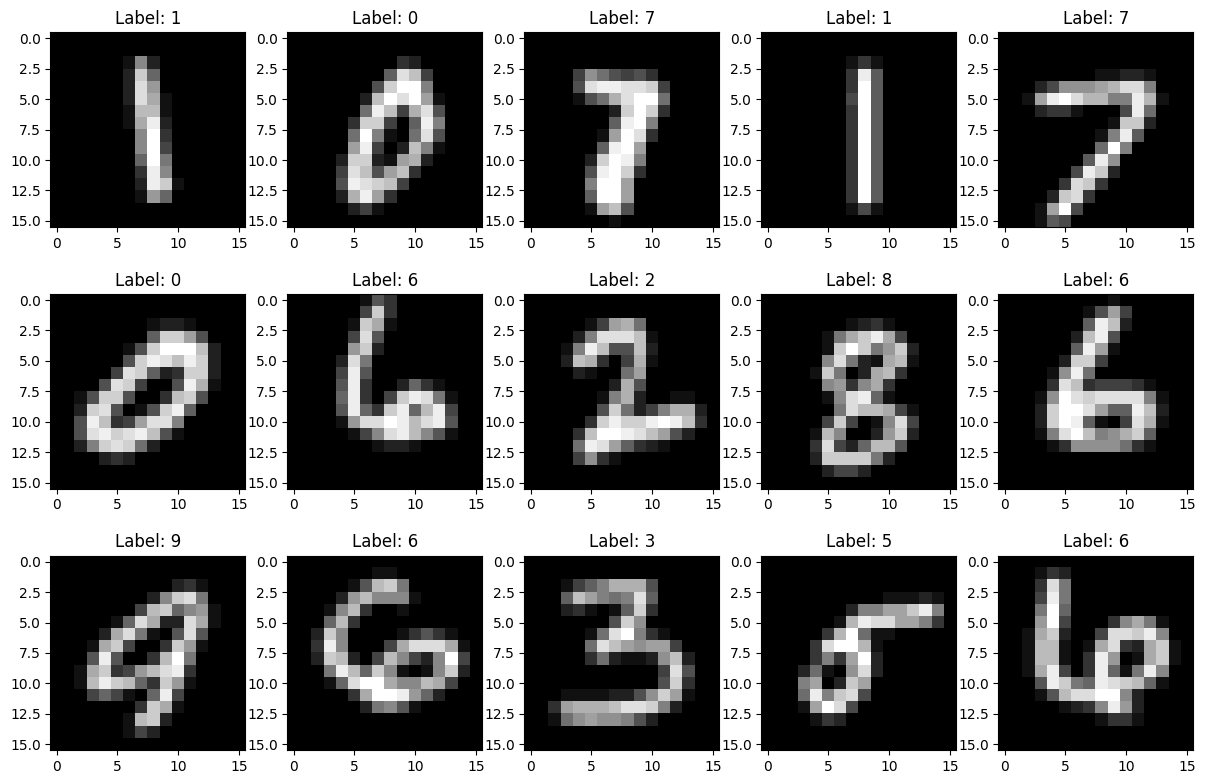

In [11]:
import joblib
import numpy as np
from experiments.QNN_integration.datasets.dataset_structure import DatasetSplit, DataBlock, DataSet
from pathlib import Path

seed = 71
rng = np.random.default_rng(seed)

mnist_digits_stratified_path = Path().absolute().parent / "QNN_integration" / "datasets" / ".MNIST_Digits_5_subsets_train_val_test_16x16.joblib"
mnist_digits_stratified = joblib.load(mnist_digits_stratified_path)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(12, 8))

axes = axes.flatten()
for ax in axes:
	i = rng.integers(0, len(mnist_digits_stratified.subsets[0].train.X))
	ax.imshow(mnist_digits_stratified.subsets[0].train.X[i], cmap=plt.cm.gray)
	ax.set_title("Label: " + str(mnist_digits_stratified.subsets[0].train.y[i]))

plt.tight_layout()
plt.show()

# CLASSICAL BASELINE TESTS

#### Classical PyTorch baseline architectures: Dense and CNN

In [13]:
import torch
import torch.nn as nn
from torch.optim import Adam
import copy

from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

class DenseBaseline(nn.Module):
	def __init__(self, num_classes=10):
		super().__init__()
		self.flatten = nn.Flatten()
		self.classical_head_dense = nn.Linear(16 * 16, num_classes)

	def forward(self, x):
		x = self.flatten(x)
		x = self.classical_head_dense(x)
		return x
	
def numpy_images_to_torch(x_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	"""
	Konwersja obrazów uint8 [0, 255] -> float32 [0, 1].
	Obsługuje wejście o kształcie:
	- (N, 16, 16)
	- (16, 16) dla pojedynczej próbki
	"""
	x_np = np.asarray(x_np)

	if x_np.ndim == 2:
		x_np = np.expand_dims(x_np, axis=0)

	x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device) / 255.0
	return x_tensor


def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_model(model, split, criterion, device="cpu", batch_size=32):
	"""
	Ewaluacja modelu na dowolnym splicie: train / val / test.
	Zwraca:
	- średnią stratę
	- metryki klasyfikacyjne
	- y_true, y_pred
	"""
	model.eval()

	x_all = numpy_images_to_torch(split.X, device=device)
	y_all = numpy_labels_to_torch(split.y, device=device)

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for start_idx in range(0, len(x_all), batch_size):
			end_idx = start_idx + batch_size

			x_batch = x_all[start_idx:end_idx]
			y_batch = y_all[start_idx:end_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_batch.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}


def train_one_block(
	data_block,
	num_classes=10,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	device="cpu",
	verbose=True
):
	"""
	Trening pojedynczego DataBlock:
	- uczy na train
	- co epokę waliduje na val
	- na końcu testuje na test
	"""
	model = DenseBaseline(num_classes=num_classes).to(device)
	criterion = nn.CrossEntropyLoss()
	optimizer = Adam(model.parameters(), lr=lr)

	x_train = numpy_images_to_torch(data_block.train.X, device=device)
	y_train = numpy_labels_to_torch(data_block.train.y, device=device)

	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	best_val_f1 = -np.inf
	best_model_state = None

	for epoch in range(epochs):
		model.train()

		indices = torch.randperm(len(x_train), device=device)

		epoch_losses = []
		epoch_preds = []
		epoch_true = []

		for start_idx in range(0, len(indices), batch_size):
			batch_idx = indices[start_idx:start_idx + batch_size]

			x_batch = x_train[batch_idx]
			y_batch = y_train[batch_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			optimizer.zero_grad()
			loss.backward()
			optimizer.step()

			preds = torch.argmax(logits, dim=1)

			epoch_losses.append(loss.item())
			epoch_preds.extend(preds.detach().cpu().numpy().tolist())
			epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

		train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
		train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

		val_results = evaluate_model(
			model=model,
			split=data_block.val,
			criterion=criterion,
			device=device,
			batch_size=batch_size
		)

		history["train_loss"].append(train_loss)
		history["train_accuracy"].append(train_metrics["accuracy"])
		history["train_precision"].append(train_metrics["precision"])
		history["train_recall"].append(train_metrics["recall"])
		history["train_f1"].append(train_metrics["f1"])

		history["val_loss"].append(val_results["loss"])
		history["val_accuracy"].append(val_results["accuracy"])
		history["val_precision"].append(val_results["precision"])
		history["val_recall"].append(val_results["recall"])
		history["val_f1"].append(val_results["f1"])

		if val_results["f1"] > best_val_f1:
			best_val_f1 = val_results["f1"]
			best_model_state = copy.deepcopy(model.state_dict())

		if verbose:
			print(
				f"Epoch {epoch + 1:03d}/{epochs:03d} | "
				f"train_loss={train_loss:.4f} | "
				f"train_acc={train_metrics['accuracy']:.4f} | "
				f"train_prec={train_metrics['precision']:.4f} | "
				f"train_rec={train_metrics['recall']:.4f} | "
				f"train_f1={train_metrics['f1']:.4f} | "
				f"val_loss={val_results['loss']:.4f} | "
				f"val_acc={val_results['accuracy']:.4f} | "
				f"val_prec={val_results['precision']:.4f} | "
				f"val_rec={val_results['recall']:.4f} | "
				f"val_f1={val_results['f1']:.4f}"
			)

	if best_model_state is not None:
		model.load_state_dict(best_model_state)

	test_results = evaluate_model(
		model=model,
		split=data_block.test,
		criterion=criterion,
		device=device,
		batch_size=batch_size
	)

	test_cm = confusion_matrix(
		test_results["y_true"],
		test_results["y_pred"],
		labels=list(range(num_classes))
	)

	if verbose:
		print("\n=== TEST RESULTS ===")
		print(f"test_loss:      {test_results['loss']:.4f}")
		print(f"test_accuracy:  {test_results['accuracy']:.4f}")
		print(f"test_precision: {test_results['precision']:.4f}")
		print(f"test_recall:    {test_results['recall']:.4f}")
		print(f"test_f1:        {test_results['f1']:.4f}")
		print("confusion_matrix:")
		print(test_cm)

	return {
		"model": model,
		"history": history,
		"test_metrics": {
			"loss": test_results["loss"],
			"accuracy": test_results["accuracy"],
			"precision": test_results["precision"],
			"recall": test_results["recall"],
			"f1": test_results["f1"],
		},
		"confusion_matrix": test_cm,
		"y_true": test_results["y_true"],
		"y_pred": test_results["y_pred"],
	}


def train_all_subsets(
	dataset,
	num_classes=10,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	device="cpu",
	verbose=True
):
	"""
	Trening dla wszystkich 5 DataBlocków w dataset.subsets.
	Zwraca listę wyników dla każdego subsetu oraz agregację końcową.
	"""
	all_results = []

	for subset_idx, data_block in enumerate(dataset.subsets):
		if verbose:
			print(f"\n{'=' * 80}")
			print(f"TRAINING SUBSET {subset_idx + 1}/{len(dataset.subsets)}")
			print(f"{'=' * 80}")

		result = train_one_block(
			data_block=data_block,
			num_classes=num_classes,
			epochs=epochs,
			batch_size=batch_size,
			lr=lr,
			device=device,
			verbose=verbose
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print(f"\n{'=' * 80}")
		print("FINAL SUMMARY ACROSS SUBSETS")
		print(f"{'=' * 80}")
		print(f"accuracy : {summary['accuracy_mean']:.4f} ± {summary['accuracy_std']:.4f}")
		print(f"precision: {summary['precision_mean']:.4f} ± {summary['precision_std']:.4f}")
		print(f"recall   : {summary['recall_mean']:.4f} ± {summary['recall_std']:.4f}")
		print(f"f1       : {summary['f1_mean']:.4f} ± {summary['f1_std']:.4f}")

	return {
		"subset_results": all_results,
		"summary": summary
	}

results = train_all_subsets(
	dataset=mnist_digits_stratified,
	num_classes=10,
	epochs=10,
	batch_size=16,
	lr=1e-3,
	device="cpu",
	verbose=True
)


TRAINING SUBSET 1/5
Epoch 001/010 | train_loss=2.1004 | train_acc=0.4017 | train_prec=0.5561 | train_rec=0.4017 | train_f1=0.3921 | val_loss=1.8952 | val_acc=0.6580 | val_prec=0.7473 | val_rec=0.6580 | val_f1=0.6536
Epoch 002/010 | train_loss=1.7296 | train_acc=0.7709 | train_prec=0.7852 | train_rec=0.7709 | train_f1=0.7686 | val_loss=1.5917 | val_acc=0.7706 | val_prec=0.7918 | val_rec=0.7706 | val_f1=0.7661
Epoch 003/010 | train_loss=1.4573 | train_acc=0.8154 | train_prec=0.8302 | train_rec=0.8154 | train_f1=0.8123 | val_loss=1.3743 | val_acc=0.7879 | val_prec=0.8099 | val_rec=0.7879 | val_f1=0.7882
Epoch 004/010 | train_loss=1.2628 | train_acc=0.8306 | train_prec=0.8349 | train_rec=0.8306 | train_f1=0.8290 | val_loss=1.2134 | val_acc=0.7922 | val_prec=0.8082 | val_rec=0.7922 | val_f1=0.7926
Epoch 005/010 | train_loss=1.1161 | train_acc=0.8328 | train_prec=0.8389 | train_rec=0.8328 | train_f1=0.8315 | val_loss=1.0933 | val_acc=0.7965 | val_prec=0.8113 | val_rec=0.7965 | val_f1=0.7970

#### Baseline B: CNN

In [14]:
import copy
import numpy as np

import torch
import torch.nn as nn
from torch.optim import Adam

from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

class SimpleCNNBaseline(nn.Module):
	def __init__(self, num_classes=10):
		super().__init__()
		self.features = nn.Sequential(
			nn.Conv2d(1, 16, kernel_size=3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2),

			nn.Conv2d(16, 32, kernel_size=3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2)
		)

		self.classifier = nn.Sequential(
			nn.Flatten(),
			nn.Linear(32 * 4 * 4, 64),
			nn.ReLU(),
			nn.Linear(64, num_classes)
		)

	def forward(self, x):
		x = self.features(x)
		x = self.classifier(x)
		return x


def numpy_images_to_torch_cnn(x_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	"""
	Konwersja obrazów uint8 [0, 255] -> float32 [0, 1]
	oraz dodanie wymiaru kanału dla CNN.

	Wejście:
	- (N, 16, 16)
	- (16, 16)

	Wyjście:
	- (N, 1, 16, 16)
	"""
	x_np = np.asarray(x_np)

	if x_np.ndim == 2:
		x_np = np.expand_dims(x_np, axis=0)

	x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device) / 255.0
	x_tensor = x_tensor.unsqueeze(1)
	return x_tensor


def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_cnn_model(model, split, criterion, device="cpu", batch_size=32):
	model.eval()

	x_all = numpy_images_to_torch_cnn(split.X, device=device)
	y_all = numpy_labels_to_torch(split.y, device=device)

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for start_idx in range(0, len(x_all), batch_size):
			end_idx = start_idx + batch_size

			x_batch = x_all[start_idx:end_idx]
			y_batch = y_all[start_idx:end_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_batch.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}


def train_one_block_cnn(
	data_block,
	num_classes=10,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	device="cpu",
	verbose=True
):
	model = SimpleCNNBaseline(num_classes=num_classes).to(device)
	criterion = nn.CrossEntropyLoss()
	optimizer = Adam(model.parameters(), lr=lr)

	x_train = numpy_images_to_torch_cnn(data_block.train.X, device=device)
	y_train = numpy_labels_to_torch(data_block.train.y, device=device)

	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	best_val_f1 = -np.inf
	best_model_state = None

	for epoch in range(epochs):
		model.train()

		indices = torch.randperm(len(x_train), device=device)

		epoch_losses = []
		epoch_preds = []
		epoch_true = []

		for start_idx in range(0, len(indices), batch_size):
			batch_idx = indices[start_idx:start_idx + batch_size]

			x_batch = x_train[batch_idx]
			y_batch = y_train[batch_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			optimizer.zero_grad()
			loss.backward()
			optimizer.step()

			preds = torch.argmax(logits, dim=1)

			epoch_losses.append(loss.item())
			epoch_preds.extend(preds.detach().cpu().numpy().tolist())
			epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

		train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
		train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

		val_results = evaluate_cnn_model(
			model=model,
			split=data_block.val,
			criterion=criterion,
			device=device,
			batch_size=batch_size
		)

		history["train_loss"].append(train_loss)
		history["train_accuracy"].append(train_metrics["accuracy"])
		history["train_precision"].append(train_metrics["precision"])
		history["train_recall"].append(train_metrics["recall"])
		history["train_f1"].append(train_metrics["f1"])

		history["val_loss"].append(val_results["loss"])
		history["val_accuracy"].append(val_results["accuracy"])
		history["val_precision"].append(val_results["precision"])
		history["val_recall"].append(val_results["recall"])
		history["val_f1"].append(val_results["f1"])

		if val_results["f1"] > best_val_f1:
			best_val_f1 = val_results["f1"]
			best_model_state = copy.deepcopy(model.state_dict())

		if verbose:
			print(
				f"Epoch {epoch + 1:03d}/{epochs:03d} | "
				f"train_loss={train_loss:.4f} | "
				f"train_acc={train_metrics['accuracy']:.4f} | "
				f"train_prec={train_metrics['precision']:.4f} | "
				f"train_rec={train_metrics['recall']:.4f} | "
				f"train_f1={train_metrics['f1']:.4f} | "
				f"val_loss={val_results['loss']:.4f} | "
				f"val_acc={val_results['accuracy']:.4f} | "
				f"val_prec={val_results['precision']:.4f} | "
				f"val_rec={val_results['recall']:.4f} | "
				f"val_f1={val_results['f1']:.4f}"
			)

	if best_model_state is not None:
		model.load_state_dict(best_model_state)

	test_results = evaluate_cnn_model(
		model=model,
		split=data_block.test,
		criterion=criterion,
		device=device,
		batch_size=batch_size
	)

	test_cm = confusion_matrix(
		test_results["y_true"],
		test_results["y_pred"],
		labels=list(range(num_classes))
	)

	if verbose:
		print("\n=== TEST RESULTS ===")
		print(f"test_loss:      {test_results['loss']:.4f}")
		print(f"test_accuracy:  {test_results['accuracy']:.4f}")
		print(f"test_precision: {test_results['precision']:.4f}")
		print(f"test_recall:    {test_results['recall']:.4f}")
		print(f"test_f1:        {test_results['f1']:.4f}")
		print("confusion_matrix:")
		print(test_cm)

	return {
		"model": model,
		"history": history,
		"test_metrics": {
			"loss": test_results["loss"],
			"accuracy": test_results["accuracy"],
			"precision": test_results["precision"],
			"recall": test_results["recall"],
			"f1": test_results["f1"],
		},
		"confusion_matrix": test_cm,
		"y_true": test_results["y_true"],
		"y_pred": test_results["y_pred"],
	}


def train_all_subsets_cnn(
	dataset,
	num_classes=10,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	device="cpu",
	verbose=True
):
	all_results = []

	for subset_idx, data_block in enumerate(dataset.subsets):
		if verbose:
			print(f"\n{'=' * 80}")
			print(f"TRAINING CNN SUBSET {subset_idx + 1}/{len(dataset.subsets)}")
			print(f"{'=' * 80}")

		result = train_one_block_cnn(
			data_block=data_block,
			num_classes=num_classes,
			epochs=epochs,
			batch_size=batch_size,
			lr=lr,
			device=device,
			verbose=verbose
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print(f"\n{'=' * 80}")
		print("FINAL SUMMARY ACROSS SUBSETS")
		print(f"{'=' * 80}")
		print(f"accuracy : {summary['accuracy_mean']:.4f} ± {summary['accuracy_std']:.4f}")
		print(f"precision: {summary['precision_mean']:.4f} ± {summary['precision_std']:.4f}")
		print(f"recall   : {summary['recall_mean']:.4f} ± {summary['recall_std']:.4f}")
		print(f"f1       : {summary['f1_mean']:.4f} ± {summary['f1_std']:.4f}")

	return {
		"subset_results": all_results,
		"summary": summary
	}


device = "cuda" if torch.cuda.is_available() else "cpu"

cnn_results = train_all_subsets_cnn(
	dataset=mnist_digits_stratified,
	num_classes=10,
	epochs=10,
	batch_size=64,
	lr=1e-3,
	device=device,
	verbose=True
)


TRAINING CNN SUBSET 1/5
Epoch 001/010 | train_loss=2.2809 | train_acc=0.1194 | train_prec=0.3551 | train_rec=0.1194 | train_f1=0.0676 | val_loss=2.2281 | val_acc=0.4069 | val_prec=0.4404 | val_rec=0.4069 | val_f1=0.3547
Epoch 002/010 | train_loss=2.1517 | train_acc=0.4408 | train_prec=0.5875 | train_rec=0.4408 | train_f1=0.3797 | val_loss=2.0201 | val_acc=0.4978 | val_prec=0.4003 | val_rec=0.4978 | val_f1=0.4166
Epoch 003/010 | train_loss=1.8402 | train_acc=0.4962 | train_prec=0.5604 | train_rec=0.4962 | train_f1=0.4480 | val_loss=1.5761 | val_acc=0.6061 | val_prec=0.7335 | val_rec=0.6061 | val_f1=0.5466
Epoch 004/010 | train_loss=1.3306 | train_acc=0.6319 | train_prec=0.6277 | train_rec=0.6319 | train_f1=0.6093 | val_loss=1.0624 | val_acc=0.7273 | val_prec=0.7508 | val_rec=0.7273 | val_f1=0.7129
Epoch 005/010 | train_loss=0.9150 | train_acc=0.7427 | train_prec=0.7413 | train_rec=0.7427 | train_f1=0.7323 | val_loss=0.7867 | val_acc=0.7749 | val_prec=0.7876 | val_rec=0.7749 | val_f1=0.

# Hybrid baselines, with using *ZZ_feature_map* encoding

Baseline C: ($16\times 16$) $\to$ PCA $\to (12) \to$ *ZZ_feature_map* $\to$ QNN $\to$ Dense

In [ ]:
import copy
import numpy as np

import torch
import torch.nn as nn
from torch.optim import Adam

from sklearn.decomposition import PCA
from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient
from qiskit_machine_learning.connectors.torch_connector import _TorchNNFunction

class QNN_Baseline_PCA(nn.Module):
	def __init__(self, num_classes=10, num_qubits=12, num_layers=1):
		super().__init__()
		self.num_qubits = num_qubits
		self.num_classes = num_classes

		# Quantum part:
		# Encoding feature vector with using ZZFeatureMap
		self.feature_map = zz_feature_map(feature_dimension=num_qubits, reps=1)

		# Variational ansatz with RX, RY, RZ rotations and CNOTs in a layered structure:
		self.ansatz = QuantumCircuit(num_qubits)
		self.ansatz_params = ParameterVector("theta", length=3 * num_qubits * num_layers)

		for layer in range(num_layers):
			offset = layer * 3 * num_qubits

			for i in range(num_qubits):
				self.ansatz.rx(self.ansatz_params[offset + i], i)
			for i in range(num_qubits):
				self.ansatz.ry(self.ansatz_params[offset + num_qubits + i], i)
			for i in range(num_qubits):
				self.ansatz.rz(self.ansatz_params[offset + 2 * num_qubits + i], i)

			if layer % 2 == 0:
				for i in range(0, num_qubits - 1, 2):
					self.ansatz.cx(i, i + 1)
			else:
				for i in range(1, num_qubits - 1, 2):
					self.ansatz.cx(i, i + 1)
				self.ansatz.cx(num_qubits - 1, 0)

		qc = QuantumCircuit(num_qubits)
		qc.compose(self.feature_map, inplace=True)
		qc.compose(self.ansatz, inplace=True)

		self.sampler = Sampler()

		self.sampler_qnn = SamplerQNN(
			circuit=qc,
			input_params=list(self.feature_map.parameters),
			weight_params=list(self.ansatz.parameters),
			sampler=self.sampler,
			gradient=ParamShiftSamplerGradient(sampler=self.sampler)
		)
		
		# self.qnn_layer = TorchConnector(self.sampler_qnn)
		self.classical_head = nn.Linear(2**num_qubits, num_classes)

		self.quantum_weight = nn.Parameter(
			torch.empty(len(self.ansatz_params)).uniform_(-np.pi, np.pi)
		)

	def forward(self, x):
		probs = _TorchNNFunction.apply(
			x,       
			list(self.feature_map.parameters),  
			self.sampler_qnn,   
			False # sparse
		)
		# Feature scaling, drastically improves training time
		# Feels illegal, but it works, just don't let the gradient police know
		scaled_probs = probs * (2 ** self.num_qubits)
		x = self.classical_head(scaled_probs)
		return torch.log_softmax(x, dim=-1)


def fit_pca_on_train_split(train_X: np.ndarray, n_components=12):
	"""
	Fits PCA only on train split.
	train_X: (N, 16, 16) uint8
	"""
	x_train = np.asarray(train_X, dtype=np.float32) / 255.0
	x_train = x_train.reshape(len(x_train), -1)

	pca = PCA(n_components=n_components)
	pca.fit(x_train)
	return pca


def transform_images_with_pca(x_np: np.ndarray, pca: PCA, device="cpu") -> torch.Tensor:
	"""
	Transforms images using an already fitted PCA.
	Input:
	- (N, 16, 16) or (16, 16)
	Output:
	- torch tensor of shape (N, n_components)
	"""
	x_np = np.asarray(x_np)

	if x_np.ndim == 2:
		x_np = np.expand_dims(x_np, axis=0)

	x_np = x_np.astype(np.float32) / 255.0
	x_np = x_np.reshape(len(x_np), -1)
	x_np = pca.transform(x_np)

	x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device)
	return x_tensor


def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_pca_qnn_model(model, split, pca, criterion, device="cpu", batch_size=32):
	model.eval()

	x_all = transform_images_with_pca(split.X, pca=pca, device=device)
	y_all = numpy_labels_to_torch(split.y, device=device)

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for start_idx in range(0, len(x_all), batch_size):
			end_idx = start_idx + batch_size

			x_batch = x_all[start_idx:end_idx]
			y_batch = y_all[start_idx:end_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_batch.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}


def train_one_block_pca_qnn(
	data_block,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	device="cpu",
	verbose=True
):
	"""
	Trains one block:
	(16x16) -> PCA(12) -> ZZFeatureMap -> QNN -> Dense
	"""
	pca = fit_pca_on_train_split(
		train_X=data_block.train.X,
		n_components=num_qubits
	)

	model = QNN_Baseline_PCA(
		num_classes=num_classes,
		num_qubits=num_qubits,
		num_layers=num_layers
	).to(device)

	f_loss = nn.NLLLoss()
	optimizer = Adam([
		{'params': model.quantum_weight, 'lr': 0.05},
		{'params': model.classical_head.parameters(), 'lr': 0.001}
	])

	x_train = transform_images_with_pca(data_block.train.X, pca=pca, device=device)
	y_train = numpy_labels_to_torch(data_block.train.y, device=device)

	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	best_val_f1 = -np.inf
	best_model_state = None

	for epoch in range(epochs):
		model.train()

		indices = torch.randperm(len(x_train), device=device)

		epoch_losses = []
		epoch_preds = []
		epoch_true = []

		for start_idx in range(0, len(indices), batch_size):
			batch_idx = indices[start_idx:start_idx + batch_size]

			x_batch = x_train[batch_idx]
			y_batch = y_train[batch_idx]

			logits = model(x_batch)
			loss = f_loss(logits, y_batch)

			optimizer.zero_grad()
			loss.backward()
			optimizer.step()

			preds = torch.argmax(logits, dim=1)

			epoch_losses.append(loss.item())
			epoch_preds.extend(preds.detach().cpu().numpy().tolist())
			epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

		train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
		train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

		val_results = evaluate_pca_qnn_model(
			model=model,
			split=data_block.val,
			pca=pca,
			criterion=f_loss,
			device=device,
			batch_size=batch_size
		)

		history["train_loss"].append(train_loss)
		history["train_accuracy"].append(train_metrics["accuracy"])
		history["train_precision"].append(train_metrics["precision"])
		history["train_recall"].append(train_metrics["recall"])
		history["train_f1"].append(train_metrics["f1"])

		history["val_loss"].append(val_results["loss"])
		history["val_accuracy"].append(val_results["accuracy"])
		history["val_precision"].append(val_results["precision"])
		history["val_recall"].append(val_results["recall"])
		history["val_f1"].append(val_results["f1"])

		if val_results["f1"] > best_val_f1:
			best_val_f1 = val_results["f1"]
			best_model_state = copy.deepcopy(model.state_dict())

		if verbose:
			print(
				f"Epoch {epoch + 1:03d}/{epochs:03d} | "
				f"train_loss={train_loss:.4f} | "
				f"train_acc={train_metrics['accuracy']:.4f} | "
				f"train_prec={train_metrics['precision']:.4f} | "
				f"train_rec={train_metrics['recall']:.4f} | "
				f"train_f1={train_metrics['f1']:.4f} | "
				f"val_loss={val_results['loss']:.4f} | "
				f"val_acc={val_results['accuracy']:.4f} | "
				f"val_prec={val_results['precision']:.4f} | "
				f"val_rec={val_results['recall']:.4f} | "
				f"val_f1={val_results['f1']:.4f}"
			)

	if best_model_state is not None:
		model.load_state_dict(best_model_state)

	test_results = evaluate_pca_qnn_model(
		model=model,
		split=data_block.test,
		pca=pca,
		criterion=f_loss,
		device=device,
		batch_size=batch_size
	)

	test_cm = confusion_matrix(
		test_results["y_true"],
		test_results["y_pred"],
		labels=list(range(num_classes))
	)

	if verbose:
		print("\n=== TEST RESULTS ===")
		print(f"test_loss:      {test_results['loss']:.4f}")
		print(f"test_accuracy:  {test_results['accuracy']:.4f}")
		print(f"test_precision: {test_results['precision']:.4f}")
		print(f"test_recall:    {test_results['recall']:.4f}")
		print(f"test_f1:        {test_results['f1']:.4f}")
		print("confusion_matrix:")
		print(test_cm)

	return {
		"model": model,
		"pca": pca,
		"history": history,
		"test_metrics": {
			"loss": test_results["loss"],
			"accuracy": test_results["accuracy"],
			"precision": test_results["precision"],
			"recall": test_results["recall"],
			"f1": test_results["f1"],
		},
		"confusion_matrix": test_cm,
		"y_true": test_results["y_true"],
		"y_pred": test_results["y_pred"],
	}


def train_all_subsets_pca_qnn(
	dataset,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	device="cpu",
	verbose=True
):
	all_results = []

	for subset_idx, data_block in enumerate(dataset.subsets):
		if verbose:
			print(f"\n{'=' * 80}")
			print(f"TRAINING PCA + ZZFeatureMap + QNN SUBSET {subset_idx + 1}/{len(dataset.subsets)}")
			print(f"{'=' * 80}")

		result = train_one_block_pca_qnn(
			data_block=data_block,
			num_classes=num_classes,
			num_qubits=num_qubits,
			num_layers=num_layers,
			epochs=epochs,
			batch_size=batch_size,
			lr=lr,
			device=device,
			verbose=verbose
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print(f"\n{'=' * 80}")
		print("FINAL SUMMARY ACROSS SUBSETS")
		print(f"{'=' * 80}")
		print(f"accuracy : {summary['accuracy_mean']:.4f} ± {summary['accuracy_std']:.4f}")
		print(f"precision: {summary['precision_mean']:.4f} ± {summary['precision_std']:.4f}")
		print(f"recall   : {summary['recall_mean']:.4f} ± {summary['recall_std']:.4f}")
		print(f"f1       : {summary['f1_mean']:.4f} ± {summary['f1_std']:.4f}")

	return {
		"subset_results": all_results,
		"summary": summary
	}


device = "cuda" if torch.cuda.is_available() else "cpu"

pca_qnn_results = train_all_subsets_pca_qnn(
	dataset=mnist_digits_stratified,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=16,
	lr=1e-3,
	device=device,
	verbose=True
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.



TRAINING PCA + ZZFeatureMap + QNN SUBSET 1/5


c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


Epoch 001/010 | train_loss=2.3030 | train_acc=0.0890 | train_prec=0.0166 | train_rec=0.0890 | train_f1=0.0248 | val_loss=2.3026 | val_acc=0.0996 | val_prec=0.0099 | val_rec=0.0996 | val_f1=0.0180
Epoch 002/010 | train_loss=2.3024 | train_acc=0.1042 | train_prec=0.0213 | train_rec=0.1042 | train_f1=0.0344 | val_loss=2.3024 | val_acc=0.0996 | val_prec=0.0099 | val_rec=0.0996 | val_f1=0.0180
Epoch 003/010 | train_loss=2.3018 | train_acc=0.1249 | train_prec=0.1603 | train_rec=0.1249 | train_f1=0.0582 | val_loss=2.3023 | val_acc=0.0952 | val_prec=0.0101 | val_rec=0.0952 | val_f1=0.0183
Epoch 004/010 | train_loss=2.3014 | train_acc=0.1498 | train_prec=0.1477 | train_rec=0.1498 | train_f1=0.0746 | val_loss=2.3022 | val_acc=0.0996 | val_prec=0.0099 | val_rec=0.0996 | val_f1=0.0180
Epoch 005/010 | train_loss=2.3010 | train_acc=0.1075 | train_prec=0.1219 | train_rec=0.1075 | train_f1=0.0396 | val_loss=2.3021 | val_acc=0.1169 | val_prec=0.0481 | val_rec=0.1169 | val_f1=0.0475


KeyboardInterrupt: 

In [17]:
import copy
import numpy as np

import torch
import torch.nn as nn
from torch.optim import Adam

from sklearn.decomposition import PCA
from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler

from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient
from qiskit_machine_learning.connectors.torch_connector import _TorchNNFunction


def create_qnn(num_qubits=12, num_layers=1):
	"""
	Builds:
	ZZFeatureMap -> variational ansatz
	and returns a SamplerQNN whose raw output has size 2**num_qubits.
	"""
	feature_map = zz_feature_map(feature_dimension=num_qubits, reps=1)

	ansatz = QuantumCircuit(num_qubits)
	ansatz_params = ParameterVector("theta", length=3 * num_qubits * num_layers)

	for layer in range(num_layers):
		offset = layer * 3 * num_qubits

		for i in range(num_qubits):
			ansatz.rx(ansatz_params[offset + i], i)
		for i in range(num_qubits):
			ansatz.ry(ansatz_params[offset + num_qubits + i], i)
		for i in range(num_qubits):
			ansatz.rz(ansatz_params[offset + 2 * num_qubits + i], i)

		if layer % 2 == 0:
			for i in range(0, num_qubits - 1, 2):
				ansatz.cx(i, i + 1)
		else:
			for i in range(1, num_qubits - 1, 2):
				ansatz.cx(i, i + 1)
			ansatz.cx(num_qubits - 1, 0)

	qc = QuantumCircuit(num_qubits)
	qc.compose(feature_map, inplace=True)
	qc.compose(ansatz, inplace=True)

	sampler = Sampler()

	qnn = SamplerQNN(
		circuit=qc,
		input_params=list(feature_map.parameters),
		weight_params=list(ansatz.parameters),
		sampler=sampler
	)

	return qnn


class QNN_Baseline_PCA_NoTorchConnector(nn.Module):
	def __init__(self, num_classes=10, num_qubits=12, num_layers=1):
		super().__init__()

		self.num_classes = num_classes
		self.num_qubits = num_qubits
		self.num_layers = num_layers

		# 1. Feature map tworzony raz
		self.feature_map = zz_feature_map(feature_dimension=num_qubits, reps=1)

		# 2. VQC tworzony raz
		self.vqc_circuit = QuantumCircuit(num_qubits)
		self.thetas = ParameterVector("theta", length=3 * num_qubits * num_layers)

		for layer in range(num_layers):
			offset = layer * 3 * num_qubits

			for i in range(num_qubits):
				self.vqc_circuit.rx(self.thetas[offset + i], i)
			for i in range(num_qubits):
				self.vqc_circuit.ry(self.thetas[offset + num_qubits + i], i)
			for i in range(num_qubits):
				self.vqc_circuit.rz(self.thetas[offset + 2 * num_qubits + i], i)

			if layer % 2 == 0:
				for i in range(0, num_qubits - 1, 2):
					self.vqc_circuit.cx(i, i + 1)
			else:
				for i in range(1, num_qubits - 1, 2):
					self.vqc_circuit.cx(i, i + 1)
				self.vqc_circuit.cx(num_qubits - 1, 0)

		# 3. Główny parametr kwantowy jako natywny nn.Parameter
		self.quantum_weight = nn.Parameter(
			torch.empty(len(self.thetas)).uniform_(-np.pi, np.pi)
		)

		# 4. Głowa klasyczna
		self.classical_head = nn.Linear(2**num_qubits, num_classes)

		# 5. Sampler + gradient jawnie
		self.sampler = Sampler()
		self.gradient = ParamShiftSamplerGradient(sampler=self.sampler)

	def _build_qnn(self):
		qc = QuantumCircuit(self.num_qubits)
		qc.compose(self.feature_map, inplace=True)
		qc.compose(self.vqc_circuit, inplace=True)

		qnn = SamplerQNN(
			circuit=qc,
			input_params=list(self.feature_map.parameters),
			weight_params=list(self.vqc_circuit.parameters),
			sampler=self.sampler,
			gradient=self.gradient,
			input_gradients=False
		)

		return qnn

	def forward(self, x):
		# x oczekiwane jako:
		# (batch, num_qubits) albo (num_qubits,)
		if x.dim() == 1:
			x = x.unsqueeze(0)

		fresh_qnn = self._build_qnn()

		probs = _TorchNNFunction.apply(
			x,
			self.quantum_weight,
			fresh_qnn,
			False
		)

		# Skalowanie sygnału z części kwantowej
		scaled_probs = probs * (2 ** self.num_qubits)

		logits = self.classical_head(scaled_probs)
		return logits


def fit_pca_on_train_split(train_X: np.ndarray, n_components=12):
	"""
	Fits PCA only on train split.
	train_X: (N, 16, 16) uint8
	"""
	x_train = np.asarray(train_X, dtype=np.float32) / 255.0
	x_train = x_train.reshape(len(x_train), -1)

	pca = PCA(n_components=n_components)
	pca.fit(x_train)
	return pca


def transform_images_with_pca(x_np: np.ndarray, pca: PCA, device="cpu") -> torch.Tensor:
	"""
	Transforms images using an already fitted PCA.
	Input:
	- (N, 16, 16) or (16, 16)
	Output:
	- torch tensor of shape (N, n_components)
	"""
	x_np = np.asarray(x_np)

	if x_np.ndim == 2:
		x_np = np.expand_dims(x_np, axis=0)

	x_np = x_np.astype(np.float32) / 255.0
	x_np = x_np.reshape(len(x_np), -1)
	x_np = pca.transform(x_np)

	x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device)
	return x_tensor


def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_pca_qnn_model(model, split, pca, criterion, device="cpu", batch_size=32):
	model.eval()

	x_all = transform_images_with_pca(split.X, pca=pca, device=device)
	y_all = numpy_labels_to_torch(split.y, device=device)

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for start_idx in range(0, len(x_all), batch_size):
			end_idx = start_idx + batch_size

			x_batch = x_all[start_idx:end_idx]
			y_batch = y_all[start_idx:end_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_batch.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}


def train_one_block_pca_qnn(
	data_block,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=20,
	batch_size=32,
	quantum_lr=5e-2,
	classical_lr=1e-3,
	device="cpu",
	verbose=True,
	debug_gradients=False
):
	"""
	Trains one block:
	(16x16) -> PCA(12) -> ZZFeatureMap -> QNN -> Dense
	"""

	pca = fit_pca_on_train_split(
		train_X=data_block.train.X,
		n_components=num_qubits
	)

	model = QNN_Baseline_PCA_NoTorchConnector(
		num_classes=num_classes,
		num_qubits=num_qubits,
		num_layers=num_layers
	).to(device)

	criterion = nn.CrossEntropyLoss()

	optimizer = Adam([
		{"params": [model.quantum_weight], "lr": quantum_lr},
		{"params": model.classical_head.parameters(), "lr": classical_lr},
	])

	x_train = transform_images_with_pca(data_block.train.X, pca=pca, device=device)
	y_train = numpy_labels_to_torch(data_block.train.y, device=device)

	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	best_val_f1 = -np.inf
	best_model_state = None

	for epoch in range(epochs):
		model.train()

		indices = torch.randperm(len(x_train), device=device)

		epoch_losses = []
		epoch_preds = []
		epoch_true = []

		for start_idx in range(0, len(indices), batch_size):
			batch_idx = indices[start_idx:start_idx + batch_size]

			x_batch = x_train[batch_idx]
			y_batch = y_train[batch_idx]

			before_q = model.quantum_weight.detach().clone() if debug_gradients else None
			before_c = model.classical_head.weight.detach().clone() if debug_gradients else None

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			optimizer.zero_grad()
			loss.backward()

			if debug_gradients:
				q_grad_norm = None
				c_grad_norm = None

				if model.quantum_weight.grad is not None:
					q_grad_norm = model.quantum_weight.grad.norm().item()

				if model.classical_head.weight.grad is not None:
					c_grad_norm = model.classical_head.weight.grad.norm().item()

			optimizer.step()

			if debug_gradients:
				q_delta = torch.norm(model.quantum_weight.detach() - before_q).item()
				c_delta = torch.norm(model.classical_head.weight.detach() - before_c).item()

				print(
					f"[DEBUG] epoch={epoch + 1} "
					f"q_grad={q_grad_norm} "
					f"c_grad={c_grad_norm} "
					f"q_delta={q_delta} "
					f"c_delta={c_delta}"
				)

			preds = torch.argmax(logits, dim=1)

			epoch_losses.append(loss.item())
			epoch_preds.extend(preds.detach().cpu().numpy().tolist())
			epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

		train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
		train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

		val_results = evaluate_pca_qnn_model(
			model=model,
			split=data_block.val,
			pca=pca,
			criterion=criterion,
			device=device,
			batch_size=batch_size
		)

		history["train_loss"].append(train_loss)
		history["train_accuracy"].append(train_metrics["accuracy"])
		history["train_precision"].append(train_metrics["precision"])
		history["train_recall"].append(train_metrics["recall"])
		history["train_f1"].append(train_metrics["f1"])

		history["val_loss"].append(val_results["loss"])
		history["val_accuracy"].append(val_results["accuracy"])
		history["val_precision"].append(val_results["precision"])
		history["val_recall"].append(val_results["recall"])
		history["val_f1"].append(val_results["f1"])

		if val_results["f1"] > best_val_f1:
			best_val_f1 = val_results["f1"]
			best_model_state = copy.deepcopy(model.state_dict())

		if verbose:
			print(
				f"Epoch {epoch + 1:03d}/{epochs:03d} | "
				f"train_loss={train_loss:.4f} | "
				f"train_acc={train_metrics['accuracy']:.4f} | "
				f"train_prec={train_metrics['precision']:.4f} | "
				f"train_rec={train_metrics['recall']:.4f} | "
				f"train_f1={train_metrics['f1']:.4f} | "
				f"val_loss={val_results['loss']:.4f} | "
				f"val_acc={val_results['accuracy']:.4f} | "
				f"val_prec={val_results['precision']:.4f} | "
				f"val_rec={val_results['recall']:.4f} | "
				f"val_f1={val_results['f1']:.4f}"
			)

	if best_model_state is not None:
		model.load_state_dict(best_model_state)

	test_results = evaluate_pca_qnn_model(
		model=model,
		split=data_block.test,
		pca=pca,
		criterion=criterion,
		device=device,
		batch_size=batch_size
	)

	test_cm = confusion_matrix(
		test_results["y_true"],
		test_results["y_pred"],
		labels=list(range(num_classes))
	)

	if verbose:
		print("\n=== TEST RESULTS ===")
		print(f"test_loss:      {test_results['loss']:.4f}")
		print(f"test_accuracy:  {test_results['accuracy']:.4f}")
		print(f"test_precision: {test_results['precision']:.4f}")
		print(f"test_recall:    {test_results['recall']:.4f}")
		print(f"test_f1:        {test_results['f1']:.4f}")
		print("confusion_matrix:")
		print(test_cm)

	return {
		"model": model,
		"pca": pca,
		"history": history,
		"test_metrics": {
			"loss": test_results["loss"],
			"accuracy": test_results["accuracy"],
			"precision": test_results["precision"],
			"recall": test_results["recall"],
			"f1": test_results["f1"],
		},
		"confusion_matrix": test_cm,
		"y_true": test_results["y_true"],
		"y_pred": test_results["y_pred"],
	}


def train_all_subsets_pca_qnn(
	dataset,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=20,
	batch_size=32,
	quantum_lr=5e-2,
	classical_lr=1e-3,
	device="cpu",
	verbose=True,
	debug_gradients=False
):
	all_results = []

	for subset_idx, data_block in enumerate(dataset.subsets):
		if verbose:
			print(f"\n{'=' * 80}")
			print(f"TRAINING PCA + ZZFeatureMap + QNN SUBSET {subset_idx + 1}/{len(dataset.subsets)}")
			print(f"{'=' * 80}")

		result = train_one_block_pca_qnn(
			data_block=data_block,
			num_classes=num_classes,
			num_qubits=num_qubits,
			num_layers=num_layers,
			epochs=epochs,
			batch_size=batch_size,
			quantum_lr=quantum_lr,
			classical_lr=classical_lr,
			device=device,
			verbose=verbose,
			debug_gradients=debug_gradients
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print(f"\n{'=' * 80}")
		print("FINAL SUMMARY ACROSS SUBSETS")
		print(f"{'=' * 80}")
		print(f"accuracy : {summary['accuracy_mean']:.4f} ± {summary['accuracy_std']:.4f}")
		print(f"precision: {summary['precision_mean']:.4f} ± {summary['precision_std']:.4f}")
		print(f"recall   : {summary['recall_mean']:.4f} ± {summary['recall_std']:.4f}")
		print(f"f1       : {summary['f1_mean']:.4f} ± {summary['f1_std']:.4f}")

	return {
		"subset_results": all_results,
		"summary": summary
	}


device = "cpu"

pca_qnn_results = train_all_subsets_pca_qnn(
	dataset=mnist_digits_stratified,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=16,
	quantum_lr=5e-2,
	classical_lr=1e-3,
	device=device,
	verbose=True,
	debug_gradients=False
)


TRAINING PCA + ZZFeatureMap + QNN SUBSET 1/5


QiskitMachineLearningError: 'Sampler job failed: ParameterVectorElement(inputs[0]) is not in list'

Baseline D: ($16\times 16$) $\to$ CNN $\to (12) \to$ *ZZ_feature_map* $\to$ QNN $\to$ Dense